In [8]:
# Imports
import pandas as pd
import re
import matplotlib.pyplot as plt

In [2]:
def extract_best_train_loss(log__file_path):
    pattern = re.compile(
        r"epoch: (\d+) \(step: (\d+)\) \| train loss: ([\d.]+) \| lr: ([\d.]+)"
    )
    records = []

    # Load and parse the log file
    with open(log__file_path, 'r') as file:
        for line in file:
            match = pattern.search(line)
            if match:
                epoch, step, train_loss, lr = match.groups()
                records.append({
                    'epoch': int(epoch),
                    'step': int(step),
                    'train_loss': float(train_loss),
                    'lr': float(lr)
                })
    
    df = pd.DataFrame(records)

    # Group by epoch, get best train_loss and corresponding lr
    sorted_df = df.sort_values(by=['epoch', 'train_loss'])
    best_per_epoch = sorted_df.drop_duplicates(subset='epoch', keep='first')
    best_per_epoch = best_per_epoch[['epoch', 'train_loss', 'lr']]
    best_per_epoch = best_per_epoch.rename(columns={'train_loss': 'best_train_loss'})
    best_per_epoch.reset_index(drop=True, inplace=True)
    return best_per_epoch

In [9]:
# Plot learning curve
def plot_loss_curve(best_per_epoch, title):
    plt.figure(figsize=(10, 5))
    plt.plot(best_per_epoch['epoch'], best_per_epoch['best_train_loss'], marker='o', linestyle='-', color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('Best Train Loss')
    plt.title(title)
    plt.grid(True)
    plt.xticks(best_per_epoch['epoch'])
    plt.tight_layout()
    plt.show()


In [16]:
best_per_epoch = extract_best_train_loss("./training.logs/outputs_ehrsql_mimic3_t5_base_train.log")
best_per_epoch.head(10)

,epoch,best_train_loss,lr
0,1,0.012208,0.0001
1,2,0.004708,0.0001
2,3,0.002552,0.0001
3,4,0.001511,0.0001
4,5,0.001010,0.0001
5,6,0.000646,0.0001
6,7,0.000444,0.0001
7,8,0.000336,0.0001
8,9,0.000297,0.0001
9,10,0.000228,0.0001


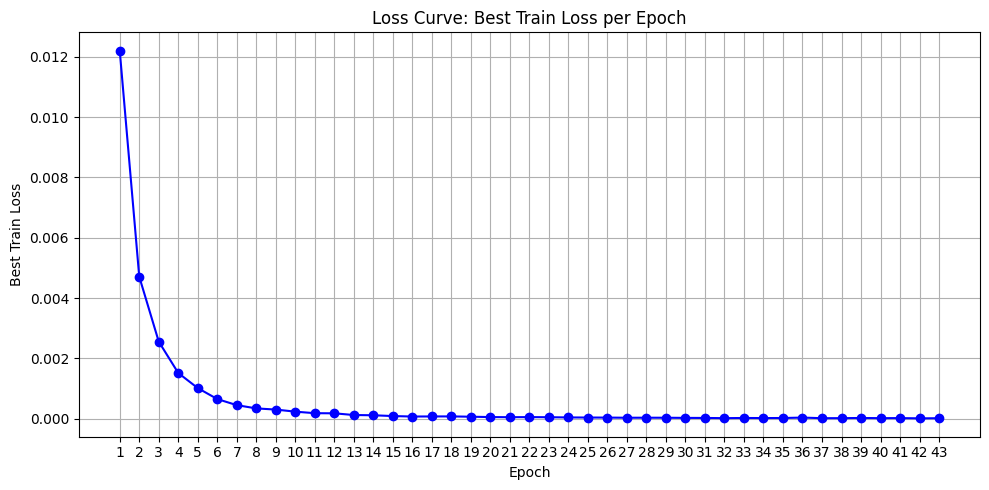

In [17]:
plot_loss_curve(best_per_epoch, 'Loss Curve: Best Train Loss per Epoch')

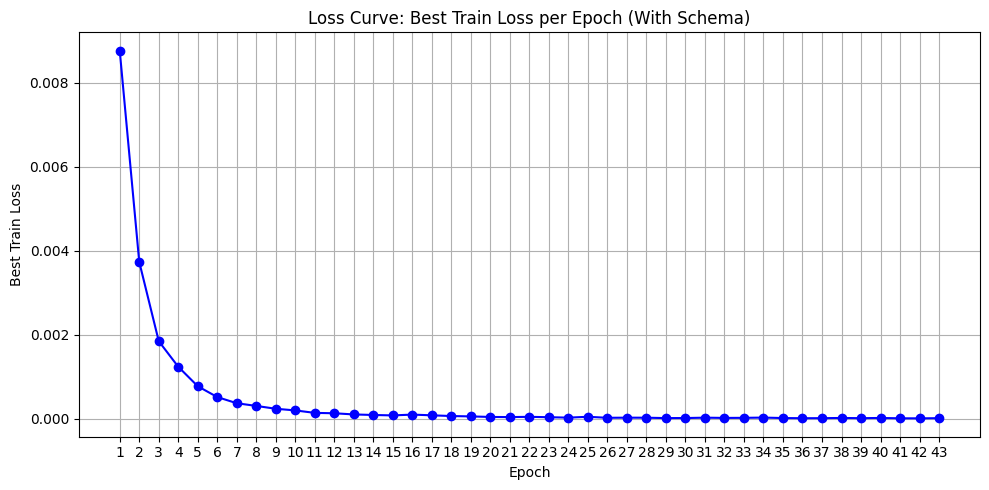

In [15]:
best_per_epoch = extract_best_train_loss("./training.logs/outputs_ehrsql_mimic3_t5_base_schema_train.log")
plot_loss_curve(best_per_epoch, 'Loss Curve: Best Train Loss per Epoch (With Schema)')